In [38]:
import pandas as pd

df = pd.read_csv('contracts_cache.csv')

df.shape

(26110, 14)

In [39]:
import plotly.express as px
import pandas as pd

# # Re-parse after potential CSV round-trip
# df["Start Date"]  = pd.to_datetime(df["Start Date"], errors="coerce")
# df                = df.dropna(subset=["Start Date"])

if "PSC_description" not in df.columns:
    df["PSC_description"] = ""
if "PSC" not in df.columns:
    df["PSC"] = "UNKNOWN"

# ------------------------------------------------------------------
# Chart 1 — PSC activity (count per code, hover shows description)
# ------------------------------------------------------------------
psc_df = df

psc_hover = (
    psc_df.groupby("PSC")
    .agg(Count=("PSC", "count"), Description=("PSC_description", "first"))
    .reset_index()
    .sort_values("Count", ascending=False)
    .head(15)
)

if psc_hover.empty:
    fig_psc = _empty_fig("Market Activity by Category (PSC Code)")
else:
    fig_psc = px.bar(
        psc_hover,
        x="Count", y="PSC", orientation="h",
        hover_data={"Description": True, "Count": True},
        title="Market Activity by Category (PSC Code)",
    )
    fig_psc.update_layout(yaxis=dict(type="category"))

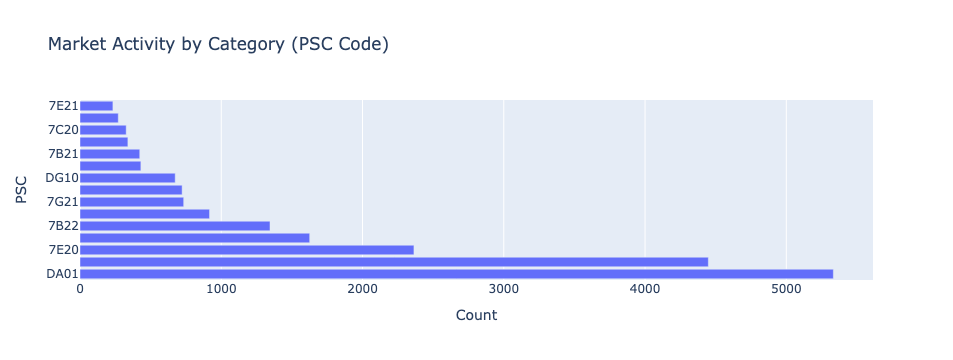

In [40]:
fig_psc

In [30]:
# Re-parse after potential CSV round-trip
df["Start Date"]  = pd.to_datetime(df["Start Date"], errors="coerce")

In [37]:
df

,internal_id,Award ID,Recipient Name,Start Date,End Date,Award Amount,Awarding Agency,Awarding Sub Agency,PSC,Description,awarding_agency_id,agency_slug,generated_internal_id,PSC_description
0,307889979,HT942524F0015,"MANTECH ADVANCED SYSTEMS INTERNATIONAL, INC.",2024-02-28,2027-02-27,1.000256e+08,Department of Defense,Defense Health Agency,DA01,TECHNICAL REFRESH TO LOGICOLE,1173,department-of-defense,CONT_AWD_HT942524F0015_9700_47QTCK18D0031_4732,IT AND TELECOM - BUSINESS APPLICATION/APPLICAT...
1,307877914,HT001525F0026,DELL MARKETING L.P.,2025-06-01,2026-05-31,9.872499e+07,Department of Defense,Defense Health Agency,7A21,MICROSOFT LICENSES AND SUPPORT,1173,department-of-defense,CONT_AWD_HT001525F0026_9700_N6600121A0083_9700,IT AND TELECOM - BUSINESS APPLICATION SOFTWARE...
2,307877752,HT001524F0082,DELL MARKETING L.P.,2024-06-01,2025-05-31,9.851165e+07,Department of Defense,Defense Health Agency,7A21,MICROSOFT LICENSES AND SUPPORT,1173,department-of-defense,CONT_AWD_HT001524F0082_9700_N6600121A0083_9700,IT AND TELECOM - BUSINESS APPLICATION SOFTWARE...
3,306512964,HC108425F0175,"KNIGHT POINT SYSTEMS, LLC",2025-04-15,2026-04-14,9.844506e+07,Department of Defense,Defense Information Systems Agency,DA01,CSCII - OPTION PERIOD 3,1173,department-of-defense,CONT_AWD_HC108425F0175_9700_HC102818D0041_9700,IT AND TELECOM - BUSINESS APPLICATION/APPLICAT...
4,349903439,W912HQ23F0004,DYNAMIC SYSTEMS INC,2022-12-23,2025-01-23,9.718156e+07,Department of Defense,Department of the Army,7E20,S22-0083 ITHC4 BASE YEAR,1173,department-of-defense,CONT_AWD_W912HQ23F0004_9700_W52P1J16D0009_9700,"IT and Telecom - End User: Help Desk;Tier 1-2,..."
5,307864999,HT001123C0103,AKIAK NS LLC,2023-09-30,2025-09-29,9.554386e+07,Department of Defense,Defense Health Agency,DA01,TECHNOLOGY LIFECYCLE SUPPORT,1173,department-of-defense,CONT_AWD_HT001123C0103_9700_-NONE-_-NONE-,IT AND TELECOM - BUSINESS APPLICATION/APPLICAT...
6,310926051,N6523624F0453,"AMAZON WEB SERVICES, INC.",2024-07-01,2026-06-30,9.475146e+07,Department of Defense,Department of the Navy,DB10,AWS CLOUD SERVICES,1173,department-of-defense,CONT_AWD_N6523624F0453_9700_N6600123A0005_9700,IT AND TELECOM - COMPUTE AS A SERVICE: MAINFRA...
7,309318865,M6785423F4031,DELL MARKETING L.P.,2023-06-01,2024-05-31,9.356556e+07,Department of Defense,Department of the Navy,7A21,PERSONA 5: POWER USER - (M365 E5) UNLIMITED WI...,1173,department-of-defense,CONT_AWD_M6785423F4031_9700_N6600121A0083_9700,IT AND TELECOM - BUSINESS APPLICATION SOFTWARE...
8,309499326,N0001924C0057,GENERAL DYNAMICS ONE SOURCE LLC,2024-08-01,2026-07-31,9.341854e+07,Department of Defense,Department of the Navy,DA01,THIS CONTRACT PROCURES TRANSITIONAL INFORMATIO...,1173,department-of-defense,CONT_AWD_N0001924C0057_9700_-NONE-_-NONE-,IT AND TELECOM - BUSINESS APPLICATION/APPLICAT...
9,348986087,W519TC24F0075,DELL FEDERAL SYSTEMS L.P,2024-01-23,2025-01-22,9.276116e+07,Department of Defense,Department of the Army,7A21,VMWARE LICENSE MAINTENANCE,1173,department-of-defense,CONT_AWD_W519TC24F0075_9700_47QTCA24A0001_4732,IT AND TELECOM - BUSINESS APPLICATION SOFTWARE...


In [41]:
nhl_mascots = {
    "ANA": "Wild Wing",
    "BOS": "Blades the Bruin",
    "BUF": "Sabretooth",
    "CGY": "Harvey the Hound",
    "CAR": "Stormy",
    "CHI": "Tommy Hawk",
    "COL": "Bernie the St. Bernard",
    "CBJ": "Stinger",
    "DAL": "Victor E. Green",
    "DET": "Al the Octopus",
    "EDM": "Hunter",
    "FLA": "Stanley C. Panther",
    "LAK":  "Bailey",
    "MIN": "Nordy",
    "MTL": "Youppi!",
    "NSH": "Gnash",
    "NJD":  "NJ Devil",
    "NYI": "Sparky the Dragon",
    "NYR": None,          # The Rangers do not have an official mascot
    "OTT": "Spartacat",
    "PHI": "Gritty",
    "PIT": "Iceburgh",
    "SJS": "Sarkie",
    "SEA": "Buoy",
    "STL": "Louie",
    "TBL": "ThunderBug",
    "TOR": "Carlton the Bear",
    "UTA": None,          # Utah HC has not yet introduced an official mascot
    "VAN": "Fin the Orca",
    "VGK": "Chance",
    "WSH": "Slapshot",
    "WPG": "Mick E. Moose"
}.keys()